# Exercise 8.2c solution


We now solve the ODE analytically. It is almost identical to the voltage clamp model we solved earlier, and we carry out a similar process. First, we substitute $u = V - E_{\mathrm{Na}}$ to find:

$$
\frac{1}{u} \frac{\mathrm{d}u}{\mathrm{d}t} = -\frac{g_{\mathrm{Na}}}{C_{\mathrm{m}}}
$$

Which is a separable ODE, yielding:

$$
u(t) = C e^{-t \cdot g_{\mathrm{Na}}/C_{\mathrm{m}}}
$$

Substituting back for $V$, we get:

$$
V(t) = E_{\mathrm{Na}} + (V_0 - E_{\mathrm{Na}})e^{-t/\tau}
$$

Where the time constant is $\tau = C_{\mathrm{m}}/g_{\mathrm{Na}}$.

We see the solution is an exponential decay toward the Nernst potential. The larger the conductance of the channels, the larger the current, and the faster the change in potential. Conversely, the larger the capacitance, the harder it is to charge the membrane, so it takes longer.

For our specific parameters, we have:

$$
\tau = \frac{C_{\mathrm{m}}}{g_{\mathrm{Na}}} = \frac{0.05 \text{ nF}}{0.005 \text{ µS}} = 10 \text{ ms}
$$


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs(t, V, Cm, g_Na, E_Na):
    return -g_Na * (V - E_Na) / Cm


T = (0, 100)
Cm = 0.05
E_Na = 70.0
g_Na = 0.005
params = (Cm, g_Na, E_Na)
y0 = (-80,)

solution = solve_ivp(rhs, T, y0, args=params, max_step=0.1)
t = solution.t
(V,) = solution.y
# ----------------------------------------------

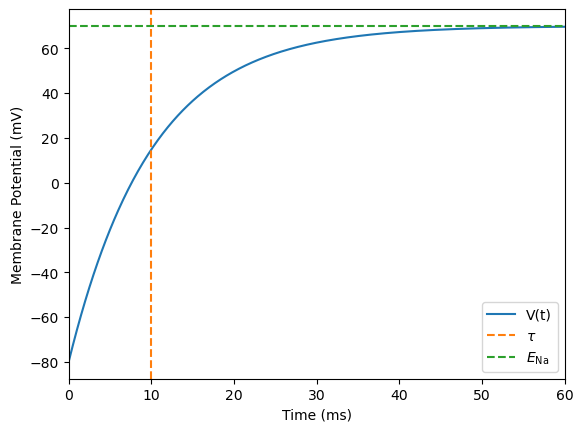

In [2]:
plt.plot(t, V, label="V(t)")
plt.axvline(10, linestyle="--", color="C1", label=r"$\tau$")
plt.axhline(E_Na, linestyle="--", color="C2", label=r"$E_{\mathrm{Na}}$")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.xlim(0, 60)
plt.legend()
plt.show()